# Testing Both Models on New Dataset

This notebook loads pre-trained TF-IDF + Logistic Regression and BERT models,
and evaluates their performance on a new labeled dataset.

## Requirements:
- New dataset CSV file with columns: 'free_text_note' and 'STATUS'
- Pre-trained models: tfidf_model.pkl, tfidf_vectorizer.pkl, bert_model_final/
- Class mapping: class_mapping.json

## Step 1: Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import json
import pickle
import re
import warnings
from datetime import datetime
from collections import Counter

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('='*70)
print('TESTING MODELS ON NEW DATASET')
print('='*70)
print(f'Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'PyTorch version: {torch.__version__}')

if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Device: Apple Metal (MPS)')
else:
    device = torch.device('cpu')
    print('Device: CPU')
print('='*70)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TESTING MODELS ON NEW DATASET
Timestamp: 2026-02-21 18:25:43
PyTorch version: 2.10.0
Device: Apple Metal (MPS)


## Step 2: Load New Dataset

In [3]:
NEW_DATA_FILE = '../data/oncology_trial_screening_v03.csv'  # Change this to your file path

print(f'Loading new dataset from: {NEW_DATA_FILE}')
new_data = pd.read_csv(NEW_DATA_FILE)

print(f'Dataset shape: {new_data.shape}')
print(f'Columns: {list(new_data.columns)}')
print(f'First few rows:')
print(new_data.head())

# Check if we have binary columns or STATUS column
binary_cols = ['deceased', 'lost_to_follow_up', 'available', 'eligible']
has_binary_cols = all(col in new_data.columns for col in binary_cols)
has_status_col = 'STATUS' in new_data.columns
has_text_col = 'free_text_note' in new_data.columns

if not has_text_col:
    raise ValueError('Dataset must have free_text_note column')

if not (has_status_col or has_binary_cols):
    raise ValueError('Dataset must have either STATUS column or binary columns (deceased, lost_to_follow_up, available, eligible)')

print('✓ Required columns present')
print(f'Missing values:')
print(new_data[['free_text_note']].isnull().sum())

new_data = new_data.dropna(subset=['free_text_note']).reset_index(drop=True)

print(f'Dataset after removing missing values: {len(new_data)} samples')
if has_status_col:
    print(f'Class distribution:')
    print(new_data['STATUS'].value_counts().sort_index())
else:
    print(f'Binary columns detected - STATUS will be created during preprocessing')

Loading new dataset from: ../data/oncology_trial_screening_v03.csv
Dataset shape: (3066, 8)
Columns: ['patient_id', 'note_date', 'cancer_indication', 'free_text_note', 'eligible', 'available', 'deceased', 'lost_to_follow_up']
First few rows:
  patient_id   note_date  cancer_indication  \
0     PT0001  2021-07-13  Pancreatic Cancer   
1     PT0001  2021-09-01  Pancreatic Cancer   
2     PT0002  2023-04-23      Breast Cancer   
3     PT0002  2023-06-27      Breast Cancer   
4     PT0002  2023-07-10      Breast Cancer   

                                      free_text_note  eligible  available  \
0  Pancreatic Cancer T4N1M0. CT: target lesion su...         0          0   
1  Pancreatic Cancer (T4N1M0). Attempted contact ...         0          0   
2  #1 — Breast Cancer (T3N0M1). PR: pos / BRCA1/2...         0          0   
3  (Breast Cancer, T3N0M1). HER2=2+ equivocal / B...         0          0   
4  Breast Cancer (T3N0M1). Attempted contact x4 o...         0          0   

   deceased 

## Step 3: Load Class Mapping and Verify Classes

## Step 2.5: Data Preprocessing (Same as Training Data)

In [4]:
# Step 1: Filter to most recent note per patient
print('\n' + '='*70)
print('DATA PREPROCESSING')
print('='*70)

print('\nStep 1: Converting note_date to datetime...')
new_data['note_date'] = pd.to_datetime(new_data['note_date'])

print('Step 2: Filtering to most recent note per patient...')
original_size = len(new_data)

new_data = new_data.sort_values(['patient_id', 'note_date'])
new_data = new_data.loc[new_data.groupby('patient_id')['note_date'].idxmax()].reset_index(drop=True)

print(f'  Original size: {original_size} rows')
print(f'  After filtering: {len(new_data)} rows')
print(f'  Unique patients: {new_data["patient_id"].nunique()}')

# Step 2: Create STATUS label from binary columns
print('\nStep 3: Creating STATUS labels from priority rules...')

def create_status_label(row):
    '''Create STATUS label based on priority rules.\n
    Priority order:\n
    1. If deceased = 1 → DECEASED\n
    2. Elif lost_to_follow_up = 1 → CENSORED\n
    3. Elif available = 1 and eligible = 1 → AVAILABLE\n
    4. Elif available = 0 and eligible = 1 → ELIGIBLE\n
    5. Else (eligible = 0) → INELIGIBLE\n
    '''
    if row.get('deceased', 0) == 1:
        return 'DECEASED'
    elif row.get('lost_to_follow_up', 0) == 1:
        return 'CENSORED'
    elif row.get('available', 0) == 1 and row.get('eligible', 0) == 1:
        return 'AVAILABLE'
    elif row.get('available', 0) == 0 and row.get('eligible', 0) == 1:
        return 'ELIGIBLE'
    else:  # eligible = 0
        return 'INELIGIBLE'

# Check if binary columns exist
binary_cols = ['deceased', 'lost_to_follow_up', 'available', 'eligible']
missing_cols = [col for col in binary_cols if col not in new_data.columns]

if missing_cols:
    print(f'  ⚠ WARNING: Missing columns for STATUS creation: {missing_cols}')
    print(f'  Your dataset appears to already have STATUS labels.')
    print(f'  Skipping STATUS creation - using existing STATUS column')
else:
    new_data['STATUS'] = new_data.apply(create_status_label, axis=1)
    print(f'  ✓ STATUS labels created')
    print(f'\n  STATUS distribution (after preprocessing):')
    for status in sorted(new_data['STATUS'].unique()):
        count = (new_data['STATUS'] == status).sum()
        pct = 100 * count / len(new_data)
        print(f'    {status:15}: {count:4} ({pct:5.1f}%)')

print('\n✓ Data preprocessing complete')
print(f'Final dataset: {len(new_data)} samples')
print('='*70)


DATA PREPROCESSING

Step 1: Converting note_date to datetime...
Step 2: Filtering to most recent note per patient...
  Original size: 3066 rows
  After filtering: 1000 rows
  Unique patients: 1000

Step 3: Creating STATUS labels from priority rules...
  ✓ STATUS labels created

  STATUS distribution (after preprocessing):
    AVAILABLE      :  132 ( 13.2%)
    CENSORED       :  155 ( 15.5%)
    DECEASED       :   80 (  8.0%)
    ELIGIBLE       :  135 ( 13.5%)
    INELIGIBLE     :  498 ( 49.8%)

✓ Data preprocessing complete
Final dataset: 1000 samples


In [5]:
with open('class_mapping.json', 'r') as f:
    class_mapping = json.load(f)

id2label = {v: k for k, v in class_mapping.items()}
label2id = class_mapping
num_labels = len(label2id)

print(f'Class mapping: {label2id}')
print(f'Number of classes: {num_labels}')

# Only check for unknown classes if STATUS already exists
if 'STATUS' in new_data.columns:
    new_classes = set(new_data['STATUS'].unique())
    known_classes = set(label2id.keys())
    unknown_classes = new_classes - known_classes
    
    if unknown_classes:
        print(f'WARNING: Found unknown classes: {unknown_classes}')
        new_data = new_data[new_data['STATUS'].isin(known_classes)].reset_index(drop=True)
        print(f'Dataset after removing unknown classes: {len(new_data)} samples')
    else:
        print('✓ All classes in new data are known')
    
    print(f'Final class distribution:')
    for cls in sorted(label2id.keys()):
        count = (new_data['STATUS'] == cls).sum()
        pct = 100 * count / len(new_data)
        print(f'  {cls:15}: {count:4} ({pct:5.1f}%)')
else:
    print('✓ STATUS column will be created in preprocessing step')

Class mapping: {'AVAILABLE': 0, 'CENSORED': 1, 'DECEASED': 2, 'ELIGIBLE': 3, 'INELIGIBLE': 4}
Number of classes: 5
✓ All classes in new data are known
Final class distribution:
  AVAILABLE      :  132 ( 13.2%)
  CENSORED       :  155 ( 15.5%)
  DECEASED       :   80 (  8.0%)
  ELIGIBLE       :  135 ( 13.5%)
  INELIGIBLE     :  498 ( 49.8%)


## Step 4: Load Pre-trained Models

In [6]:
print('\n' + '='*70)
print('LOADING PRE-TRAINED MODELS')
print('='*70)

print('Loading TF-IDF + Logistic Regression...')
with open('tfidf_model.pkl', 'rb') as f:
    tfidf_lr_model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)
print('✓ TF-IDF model loaded')

print('Loading BERT model...')
bert_tokenizer = AutoTokenizer.from_pretrained('./bert_model_final')
bert_model = AutoModelForSequenceClassification.from_pretrained('./bert_model_final')
bert_model.to(device)
bert_model.eval()
print('✓ BERT model loaded')

print('\n✓ All models loaded successfully')
print('='*70)


LOADING PRE-TRAINED MODELS
Loading TF-IDF + Logistic Regression...
✓ TF-IDF model loaded
Loading BERT model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1866.64it/s, Materializing param=classifier.weight]                                      


✓ BERT model loaded

✓ All models loaded successfully


## Step 5: Prepare Data for TF-IDF Model

In [7]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\\b\\d+\\.?\\d*\\b', '', text)
    text = re.sub(r'[^a-zA-Z\\s\\-]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

print('Preprocessing text for TF-IDF...')
new_texts = [preprocess_text(text) for text in new_data['free_text_note']]

print('Vectorizing with TF-IDF...')
X_new = tfidf_vectorizer.transform(new_texts)

print(f'✓ TF-IDF feature matrix shape: {X_new.shape}')

Preprocessing text for TF-IDF...
Vectorizing with TF-IDF...
✓ TF-IDF feature matrix shape: (1000, 1622)


## Step 6: Get TF-IDF Model Predictions

In [8]:
print('\n' + '='*70)
print('TF-IDF + LOGISTIC REGRESSION PREDICTIONS')
print('='*70)

tfidf_predictions = tfidf_lr_model.predict(X_new)
tfidf_probabilities = tfidf_lr_model.predict_proba(X_new)

y_true = np.array([label2id[status] for status in new_data['STATUS']])
tfidf_pred_numeric = np.array([label2id[pred] for pred in tfidf_predictions])

print(f'Predictions generated for {len(tfidf_predictions)} samples')
print(f'Prediction classes: {np.unique(tfidf_predictions)}')


TF-IDF + LOGISTIC REGRESSION PREDICTIONS
Predictions generated for 1000 samples
Prediction classes: ['AVAILABLE' 'CENSORED' 'DECEASED' 'INELIGIBLE']


## Step 7: Prepare Data for BERT Model

In [9]:
print('Preparing data for BERT...')
from datasets import Dataset

bert_dataset = Dataset.from_pandas(new_data[['free_text_note', 'STATUS']])

def preprocess_function(examples):
    return bert_tokenizer(
        examples['free_text_note'],
        padding='max_length',
        max_length=256,
        truncation=True,
        return_tensors='pt'
    )

# Tokenize
bert_dataset = bert_dataset.map(
    lambda x: preprocess_function({'free_text_note': x['free_text_note']}),
    batched=True,
    remove_columns=['free_text_note']
)

# Create a mapping of STATUS to labels before adding to dataset
# This avoids index issues with the dataset map function
status_labels = new_data['STATUS'].values

def add_labels(example, idx):
    example['labels'] = label2id[status_labels[idx]]
    return example

# Add labels using with_indices
bert_dataset = bert_dataset.map(
    add_labels,
    with_indices=True
)

bert_dataset.set_format('torch')

print(f'✓ BERT dataset prepared')

Preparing data for BERT...


Map: 100%|██████████| 1000/1000 [00:00<00:00, 39695.11 examples/s]

✓ BERT dataset prepared


## Step 8: Get BERT Model Predictions

In [10]:
print('\n' + '='*70)
print('BERT MODEL PREDICTIONS')
print('='*70)

print('Generating BERT predictions...')

bert_all_logits = []
batch_size = 8

with torch.no_grad():
    for i in range(0, len(bert_dataset), batch_size):
        batch = bert_dataset[i:min(i+batch_size, len(bert_dataset))]
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.cpu().numpy()
        bert_all_logits.append(logits)
        
        if (i + batch_size) % 32 == 0:
            print(f'  Processed {min(i+batch_size, len(bert_dataset))}/{len(bert_dataset)} samples')

bert_logits = np.vstack(bert_all_logits)
bert_probabilities = torch.softmax(torch.tensor(bert_logits), dim=1).numpy()
bert_pred_numeric = np.argmax(bert_logits, axis=1)
bert_predictions = np.array([id2label[pred_id] for pred_id in bert_pred_numeric])

print(f'✓ BERT predictions generated for {len(bert_predictions)} samples')
print(f'Prediction classes: {np.unique(bert_predictions)}')


BERT MODEL PREDICTIONS
Generating BERT predictions...
  Processed 32/1000 samples
  Processed 64/1000 samples
  Processed 96/1000 samples
  Processed 128/1000 samples
  Processed 160/1000 samples
  Processed 192/1000 samples
  Processed 224/1000 samples
  Processed 256/1000 samples
  Processed 288/1000 samples
  Processed 320/1000 samples
  Processed 352/1000 samples
  Processed 384/1000 samples
  Processed 416/1000 samples
  Processed 448/1000 samples
  Processed 480/1000 samples
  Processed 512/1000 samples
  Processed 544/1000 samples
  Processed 576/1000 samples
  Processed 608/1000 samples
  Processed 640/1000 samples
  Processed 672/1000 samples
  Processed 704/1000 samples
  Processed 736/1000 samples
  Processed 768/1000 samples
  Processed 800/1000 samples
  Processed 832/1000 samples
  Processed 864/1000 samples
  Processed 896/1000 samples
  Processed 928/1000 samples
  Processed 960/1000 samples
  Processed 992/1000 samples
✓ BERT predictions generated for 1000 samples
Pre

## Step 9: Evaluate Both Models

In [11]:
def compute_metrics(y_true, y_pred, y_pred_numeric, y_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred_numeric)
    weighted_f1 = f1_score(y_true, y_pred_numeric, average='weighted', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred_numeric, average='macro', zero_division=0)
    weighted_precision = precision_score(y_true, y_pred_numeric, average='weighted', zero_division=0)
    weighted_recall = recall_score(y_true, y_pred_numeric, average='weighted', zero_division=0)
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_precision,
        'weighted_recall': weighted_recall,
        'y_pred': y_pred,
        'y_pred_numeric': y_pred_numeric,
        'y_proba': y_proba,
    }

print('\n' + '='*70)
print('MODEL EVALUATION RESULTS')
print('='*70)

tfidf_metrics = compute_metrics(y_true, tfidf_predictions, tfidf_pred_numeric, 
                                 tfidf_probabilities, 'TF-IDF + LR')
bert_metrics = compute_metrics(y_true, bert_predictions, bert_pred_numeric,
                                bert_probabilities, 'BERT')

print('\nTF-IDF + LOGISTIC REGRESSION:')
print(f'  Accuracy:            {tfidf_metrics["accuracy"]:.4f}')
print(f'  Weighted F1:         {tfidf_metrics["weighted_f1"]:.4f}')
print(f'  Macro F1:            {tfidf_metrics["macro_f1"]:.4f}')
print(f'  Weighted Precision:  {tfidf_metrics["weighted_precision"]:.4f}')
print(f'  Weighted Recall:     {tfidf_metrics["weighted_recall"]:.4f}')

print('\nBERT:')
print(f'  Accuracy:            {bert_metrics["accuracy"]:.4f}')
print(f'  Weighted F1:         {bert_metrics["weighted_f1"]:.4f}')
print(f'  Macro F1:            {bert_metrics["macro_f1"]:.4f}')
print(f'  Weighted Precision:  {bert_metrics["weighted_precision"]:.4f}')
print(f'  Weighted Recall:     {bert_metrics["weighted_recall"]:.4f}')

print('\n' + '='*70)
print('DIFFERENCE (BERT - TF-IDF):')
print('='*70)
acc_diff = bert_metrics['accuracy'] - tfidf_metrics['accuracy']
f1_diff = bert_metrics['weighted_f1'] - tfidf_metrics['weighted_f1']

print(f'  Accuracy difference:     {acc_diff:+.4f}')
print(f'  Weighted F1 difference:  {f1_diff:+.4f}')


MODEL EVALUATION RESULTS

TF-IDF + LOGISTIC REGRESSION:
  Accuracy:            0.5860
  Weighted F1:         0.4805
  Macro F1:            0.3655
  Weighted Precision:  0.6389
  Weighted Recall:     0.5860

BERT:
  Accuracy:            0.7860
  Weighted F1:         0.7473
  Macro F1:            0.6367
  Weighted Precision:  0.8143
  Weighted Recall:     0.7860

DIFFERENCE (BERT - TF-IDF):
  Accuracy difference:     +0.2000
  Weighted F1 difference:  +0.2668


## Step 10: Classification Reports

In [12]:
print('\n' + '='*70)
print('TF-IDF - CLASSIFICATION REPORT')
print('='*70)
print(classification_report(
    y_true, tfidf_pred_numeric,
    target_names=[id2label[i] for i in range(num_labels)],
    zero_division=0
))

print('\n' + '='*70)
print('BERT - CLASSIFICATION REPORT')
print('='*70)
print(classification_report(
    y_true, bert_pred_numeric,
    target_names=[id2label[i] for i in range(num_labels)],
    zero_division=0
))


TF-IDF - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   AVAILABLE       1.00      0.01      0.02       132
    CENSORED       1.00      0.34      0.51       155
    DECEASED       1.00      0.42      0.60        80
    ELIGIBLE       0.00      0.00      0.00       135
  INELIGIBLE       0.55      1.00      0.71       498

    accuracy                           0.59      1000
   macro avg       0.71      0.35      0.37      1000
weighted avg       0.64      0.59      0.48      1000


BERT - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   AVAILABLE       0.78      0.29      0.42       132
    CENSORED       0.69      0.97      0.81       155
    DECEASED       1.00      0.14      0.24        80
    ELIGIBLE       1.00      0.73      0.85       135
  INELIGIBLE       0.78      0.98      0.87       498

    accuracy                           0.79      1000
   macro avg       0.85      0.62      0.64      1000
weighted avg   

## Step 11: Confusion Matrices

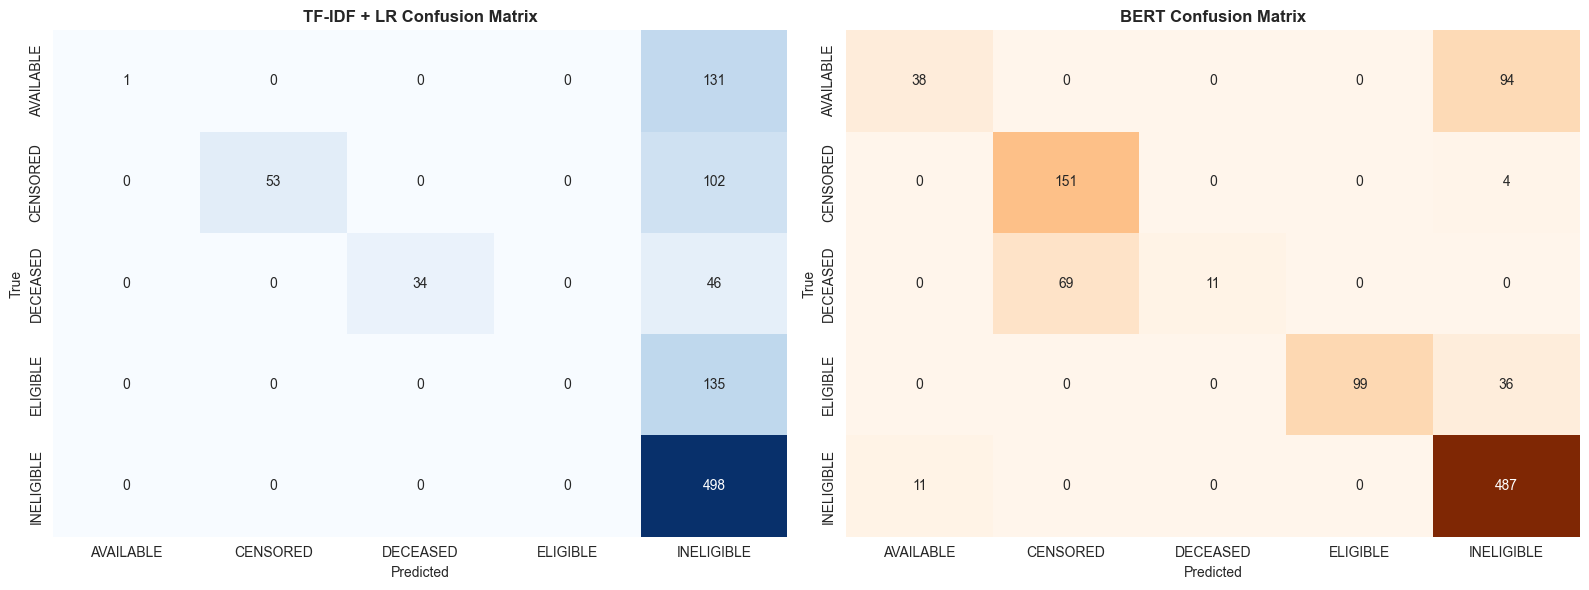

✓ Confusion matrices saved


In [13]:
tfidf_cm = confusion_matrix(y_true, tfidf_pred_numeric)
bert_cm = confusion_matrix(y_true, bert_pred_numeric)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(tfidf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)],
            cbar=False)
axes[0].set_title('TF-IDF + LR Confusion Matrix', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)],
            cbar=False)
axes[1].set_title('BERT Confusion Matrix', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('new_data_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Confusion matrices saved')

## Step 12: Performance Comparison

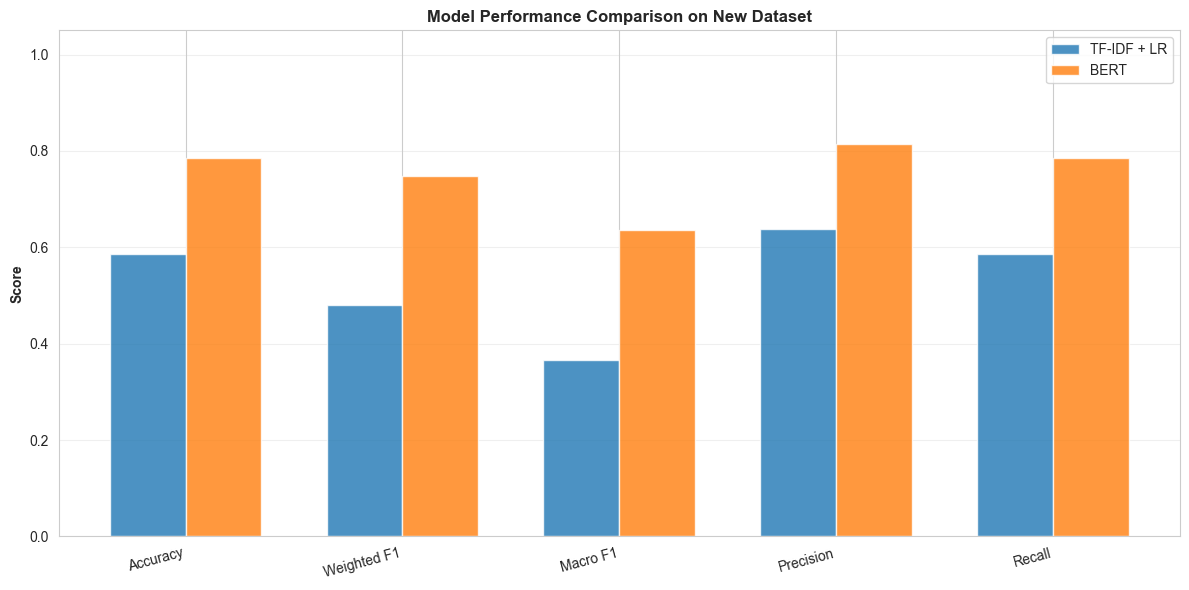

✓ Comparison chart saved


In [14]:
comparison_data = {
    'Metric': ['Accuracy', 'Weighted F1', 'Macro F1', 'Precision', 'Recall'],
    'TF-IDF + LR': [
        tfidf_metrics['accuracy'],
        tfidf_metrics['weighted_f1'],
        tfidf_metrics['macro_f1'],
        tfidf_metrics['weighted_precision'],
        tfidf_metrics['weighted_recall'],
    ],
    'BERT': [
        bert_metrics['accuracy'],
        bert_metrics['weighted_f1'],
        bert_metrics['macro_f1'],
        bert_metrics['weighted_precision'],
        bert_metrics['weighted_recall'],
    ]
}

comparison_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['TF-IDF + LR'], width, 
       label='TF-IDF + LR', color='#1f77b4', alpha=0.8)
ax.bar(x + width/2, comparison_df['BERT'], width,
       label='BERT', color='#ff7f0e', alpha=0.8)

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Model Performance Comparison on New Dataset', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'], rotation=15, ha='right')
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('new_data_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Comparison chart saved')

## Step 13: Save Predictions

In [15]:
predictions_df = pd.DataFrame({
    'true_label': new_data['STATUS'],
    'tfidf_prediction': tfidf_predictions,
    'bert_prediction': bert_predictions,
    'tfidf_confidence': tfidf_probabilities.max(axis=1),
    'bert_confidence': bert_probabilities.max(axis=1),
    'models_agree': tfidf_predictions == bert_predictions,
    'tfidf_correct': tfidf_predictions == new_data['STATUS'].values,
    'bert_correct': bert_predictions == new_data['STATUS'].values,
})

predictions_df.to_csv('new_data_predictions.csv', index=False)
print('✓ Predictions saved to new_data_predictions.csv')
print(f'\nPrediction summary:')
print(f'  Models agree: {predictions_df["models_agree"].sum()}/{len(predictions_df)}')
print(f'  Both correct: {((predictions_df["tfidf_correct"]) & (predictions_df["bert_correct"])).sum()}')
print(f'\nFirst few rows:')
print(predictions_df.head(10))

✓ Predictions saved to new_data_predictions.csv

Prediction summary:
  Models agree: 686/1000
  Both correct: 552

First few rows:
   true_label tfidf_prediction bert_prediction  tfidf_confidence  \
0    CENSORED         CENSORED        CENSORED          0.433670   
1    CENSORED         CENSORED        CENSORED          0.445414   
2    ELIGIBLE       INELIGIBLE        ELIGIBLE          0.670482   
3  INELIGIBLE       INELIGIBLE      INELIGIBLE          0.638365   
4  INELIGIBLE       INELIGIBLE      INELIGIBLE          0.607602   
5   AVAILABLE       INELIGIBLE      INELIGIBLE          0.591438   
6  INELIGIBLE       INELIGIBLE      INELIGIBLE          0.677747   
7    CENSORED         CENSORED        CENSORED          0.455144   
8    ELIGIBLE       INELIGIBLE        ELIGIBLE          0.645706   
9    CENSORED       INELIGIBLE        CENSORED          0.456161   

   bert_confidence  models_agree  tfidf_correct  bert_correct  
0         0.917471          True           True         

## Step 14: Summary

In [16]:
print('\n' + '='*70)
print('FINAL SUMMARY')
print('='*70)

summary_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted F1', 'Macro F1', 'Precision', 'Recall'],
    'TF-IDF + LR': [
        f"{tfidf_metrics['accuracy']:.4f}",
        f"{tfidf_metrics['weighted_f1']:.4f}",
        f"{tfidf_metrics['macro_f1']:.4f}",
        f"{tfidf_metrics['weighted_precision']:.4f}",
        f"{tfidf_metrics['weighted_recall']:.4f}",
    ],
    'BERT': [
        f"{bert_metrics['accuracy']:.4f}",
        f"{bert_metrics['weighted_f1']:.4f}",
        f"{bert_metrics['macro_f1']:.4f}",
        f"{bert_metrics['weighted_precision']:.4f}",
        f"{bert_metrics['weighted_recall']:.4f}",
    ]
})

print('\n')
print(summary_table.to_string(index=False))

print('\n' + '='*70)
print('✓ EVALUATION COMPLETE')
print('='*70)
print('\nGenerated files:')
print('  - new_data_confusion_matrices.png')
print('  - new_data_comparison.png')
print('  - new_data_predictions.csv')
print('='*70)


FINAL SUMMARY


     Metric TF-IDF + LR   BERT
   Accuracy      0.5860 0.7860
Weighted F1      0.4805 0.7473
   Macro F1      0.3655 0.6367
  Precision      0.6389 0.8143
     Recall      0.5860 0.7860

✓ EVALUATION COMPLETE

Generated files:
  - new_data_confusion_matrices.png
  - new_data_comparison.png
  - new_data_predictions.csv
